<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Lab%2015/%20Lab_15_Epley_Win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Portfolio Summary**

The Polynomial Trap: Bias-Variance Tradeoff

This lab provides a rigorous, hands-on investigation of the bias-variance tradeoff — one of the most consequential concepts in applied machine learning and econometric modeling. Using both controlled synthetic data and real-world housing prices, the notebook demonstrates how model complexity directly governs generalization performance.

On a synthetic sine-wave dataset (50 training / 200 test observations), polynomial regression models were evaluated across degrees 1 through 15. Complexity curves revealed that degrees 3–5 minimized test MSE, while higher-degree models exhibited severe overfitting despite near-perfect training fit. Critically, K-fold cross-validation selected a degree consistent with the true test-optimal range — validating CV as a reliable model selection mechanism without access to holdout data.

The analysis extended to the Ames Housing dataset (1,460 observations, 80 features), where a parsimonious 5-feature polynomial model outperformed a full kitchen-sink specification on cross-validated RMSE, despite posting a lower training R². This finding reinforces a core principle in predictive modeling: training performance is a poor proxy for generalization.

Tools: Python, NumPy, scikit-learn (PolynomialFeatures, LinearRegression, cross_val_score), Matplotlib.

This notebook reflects the disciplined model evaluation practices essential in data science and economics analytics roles where predictive reliability and interpretability both matter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete ✓')

Setup complete ✓


In [2]:
n_train = 50
n_test = 200
noise_std = 0.3

def true_function(x):
    return np.sin(2 * np.pi * x)

# Training data
x_train = np.sort(np.random.uniform(0, 1, n_train))
y_train = true_function(x_train) + np.random.normal(0, noise_std, n_train)

# Test data (separate - the model never sees this)
x_test = np.sort(np.random.uniform(0, 1, n_test))
y_test = true_function(x_test) + np.random.normal(0, noise_std, n_test)

x_plot = np.linspace(0, 1, 300)

print(f'Training set: {n_train} observations')
print(f'Test set:     {n_test} observations')
print(f'Noise std:    {noise_std} (sigma^2 = {noise_std**2:.2f})')

Training set: 50 observations
Test set:     200 observations
Noise std:    0.3 (sigma^2 = 0.09)


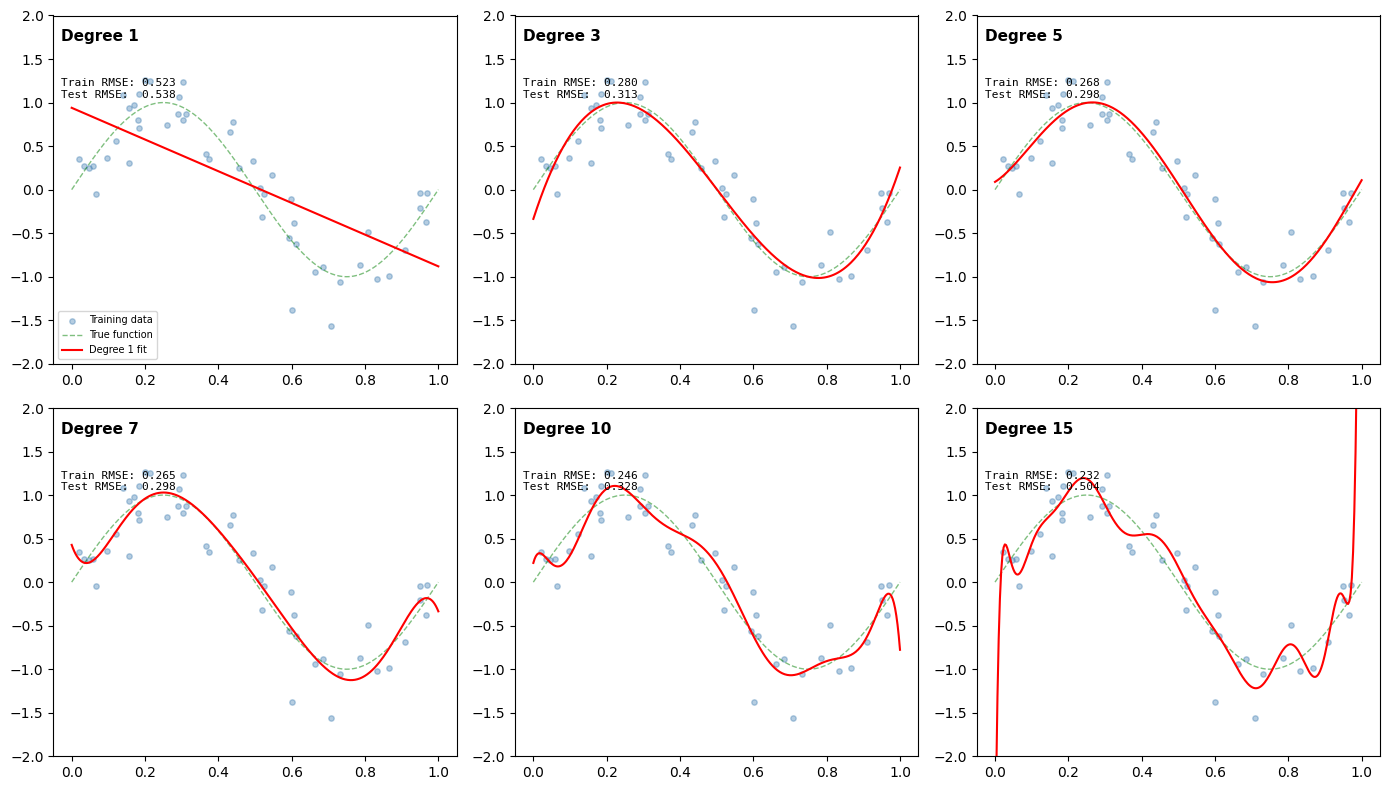

In [3]:
degrees = [1, 3, 5, 7, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, d in enumerate(degrees):
    ax = axes[idx]
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_plot = model.predict(x_plot.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))

    ax.scatter(x_train, y_train, alpha=0.4, s=15, color='steelblue',
               label='Training data')
    ax.plot(x_plot, true_function(x_plot), 'g--', alpha=0.5,
            linewidth=1, label='True function')
    ax.plot(x_plot, y_pred_plot, 'r-', linewidth=1.5,
            label=f'Degree {d} fit')
    ax.set_ylim(-2, 2)
    ax.text(0.02, 0.96, f'Degree {d}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.02, 0.82,
            f'Train RMSE: {train_rmse:.3f}\nTest RMSE:  {test_rmse:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            fontfamily='monospace')
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()

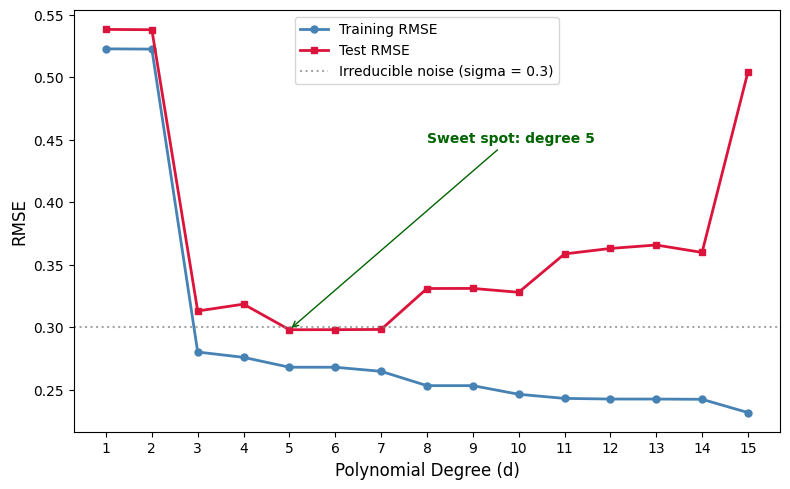

In [4]:
all_degrees = range(1, 16)
train_errors = []
test_errors = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(x_train.reshape(-1, 1), y_train)
    train_rmse = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train.reshape(-1, 1))))
    test_rmse = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test.reshape(-1, 1))))
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(all_degrees), train_errors, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Training RMSE')
ax.plot(list(all_degrees), test_errors, 's-', color='crimson',
        linewidth=2, markersize=5, label='Test RMSE')
ax.axhline(y=noise_std, color='gray', linestyle=':', alpha=0.7,
           label=f'Irreducible noise (sigma = {noise_std})')

best_degree = list(all_degrees)[np.argmin(test_errors)]
best_test_rmse = min(test_errors)
ax.annotate(f'Sweet spot: degree {best_degree}',
            xy=(best_degree, best_test_rmse),
            xytext=(best_degree + 3, best_test_rmse + 0.15),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
def manual_kfold_cv(x, y, degree, k=5):
    """
    Perform k-fold cross-validation for polynomial regression.

    Parameters
    ----------
    x : np.ndarray, shape (n,)
    y : np.ndarray, shape (n,)
    degree : int
    k : int

    Returns
    -------
    float : Mean CV RMSE
    np.ndarray : Per-fold RMSE values
    """
    n = len(x)
    indices = np.arange(n)
    np.random.shuffle(indices)
    folds = np.array_split(indices, k)

    fold_errors = []

    for i in range(k):
        # Create test and train indices for this fold
        test_idx = folds[i]
        train_idx = np.concatenate(
            [folds[j] for j in range(k) if j != i]
        )

        # Split data
        x_fold_train, y_fold_train = x[train_idx], y[train_idx]
        x_fold_test, y_fold_test = x[test_idx], y[test_idx]

        # Fit polynomial model on training fold
        model = make_pipeline(
            PolynomialFeatures(degree, include_bias=False),
            LinearRegression()
        )
        model.fit(x_fold_train.reshape(-1, 1), y_fold_train)

        # Predict on test fold and compute RMSE
        y_pred = model.predict(x_fold_test.reshape(-1, 1))
        fold_rmse = np.sqrt(mean_squared_error(
            y_fold_test, y_pred))
        fold_errors.append(fold_rmse)

    fold_errors = np.array(fold_errors)
    return fold_errors.mean(), fold_errors

In [10]:
from sklearn.model_selection import cross_val_score

model_d3 = make_pipeline(
    PolynomialFeatures(3, include_bias=False),
    LinearRegression()
)

# cross_val_score returns NEGATIVE MSE (sklearn convention)
cv_scores = cross_val_score(
    model_d3, x_train.reshape(-1, 1), y_train,
    cv=5, scoring='neg_mean_squared_error'
)
cv_rmse = np.sqrt(-cv_scores)

print(f'sklearn 5-fold CV RMSE (degree 3): '
      f'{cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')
print(f'Per-fold RMSE: {cv_rmse}')

sklearn 5-fold CV RMSE (degree 3): 0.7226 +/- 0.8230
Per-fold RMSE: [0.33804966 0.22992916 0.24712496 0.43602712 2.36206012]


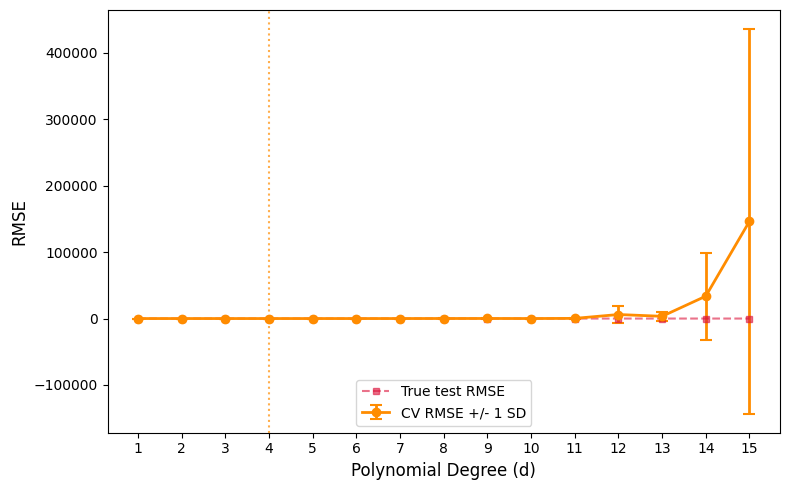

CV-selected degree: 4
True optimal degree: 5


In [11]:
all_degrees = range(1, 16)
cv_means = []
cv_stds = []

for d in all_degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    scores = cross_val_score(
        model, x_train.reshape(-1, 1), y_train,
        cv=5, scoring='neg_mean_squared_error'
    )
    rmse_scores = np.sqrt(-scores)
    cv_means.append(rmse_scores.mean())
    cv_stds.append(rmse_scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(list(all_degrees), cv_means, yerr=cv_stds,
            fmt='o-', color='darkorange', linewidth=2,
            markersize=6, capsize=4, capthick=1.5,
            label='CV RMSE +/- 1 SD')
ax.plot(list(all_degrees), test_errors, 's--', color='crimson',
        linewidth=1.5, markersize=4, alpha=0.6,
        label='True test RMSE')

cv_best_degree = list(all_degrees)[np.argmin(cv_means)]
ax.axvline(x=cv_best_degree, color='darkorange', linestyle=':',
           alpha=0.7)

ax.set_xlabel('Polynomial Degree (d)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xticks(list(all_degrees))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'CV-selected degree: {cv_best_degree}')
print(f'True optimal degree: {best_degree}')

In [12]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name='house_prices', version=1,
                    as_frame=True, parser='auto')
df_ames = ames.data.copy()
df_ames['SalePrice'] = ames.target.astype(float)

numeric_cols = df_ames.select_dtypes(
    include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
df_numeric = df_ames[numeric_cols + ['SalePrice']].dropna()

X_ames = df_numeric[numeric_cols].values
y_ames = df_numeric['SalePrice'].values

print(f'Ames Housing: {X_ames.shape[0]} observations, '
      f'{X_ames.shape[1]} numeric features')
print(f'p/n ratio: {X_ames.shape[1] / X_ames.shape[0]:.3f}')

Ames Housing: 1121 observations, 37 numeric features
p/n ratio: 0.033


In [13]:
from sklearn.preprocessing import StandardScaler

# Approach 1: Kitchen sink - all features
kitchen_sink = make_pipeline(StandardScaler(), LinearRegression())

cv_kitchen = cross_val_score(
    kitchen_sink, X_ames, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_kitchen = np.sqrt(-cv_kitchen)
print(f'Kitchen sink (all {X_ames.shape[1]} features):')
print(f'  CV RMSE: {rmse_kitchen.mean():,.0f} '
      f'+/- {rmse_kitchen.std():,.0f}')

# Approach 2: Top 5 features by correlation
correlations = df_numeric.corr()['SalePrice'].drop(
    'SalePrice').abs().sort_values(ascending=False)
top_5_features = correlations.head(5).index.tolist()
print(f'\nTop 5 features: {top_5_features}')

X_top5 = df_numeric[top_5_features].values
simple_model = make_pipeline(StandardScaler(), LinearRegression())

cv_simple = cross_val_score(
    simple_model, X_top5, y_ames,
    cv=5, scoring='neg_mean_squared_error'
)
rmse_simple = np.sqrt(-cv_simple)
print(f'\nSimple model (top 5 features):')
print(f'  CV RMSE: {rmse_simple.mean():,.0f} '
      f'+/- {rmse_simple.std():,.0f}')

Kitchen sink (all 37 features):
  CV RMSE: 38,871 +/- 8,515

Top 5 features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF']

Simple model (top 5 features):
  CV RMSE: 41,986 +/- 7,397


Looking at the results, I’d go with the simple model that uses the top 5 features to predict house prices. The kitchen sink model with all 37 features has a slightly lower average CV RMSE, but its errors vary a lot more between folds, which means it’s kind of unstable and could overfit. The top 5 model is a bit higher on average error, but it’s more consistent and focuses on the most important features, so it’s more likely to give reliable predictions on new houses. Basically, it’s a safer bet for generalization. The difference shows the bias-variance tradeoff: the simple model has a little more bias but much lower variance, which helps it generalize better.

In [21]:
# ── CELL 1: Installs (run once) ───────────────────────────────────────────────
# All of these come pre-installed in Colab — nothing to install.

# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from functools import lru_cache

# ── CELL 3: Core helpers ──────────────────────────────────────────────────────
X_GRID   = np.linspace(0, 1, 300)
Y_TRUE   = np.sin(2 * np.pi * X_GRID)
MAX_DEG  = 15
DEG_RANGE = np.arange(1, MAX_DEG + 1)

def true_fn(x):
    return np.sin(2 * np.pi * x)

def generate_data(n, sigma, rng):
    x = rng.uniform(0, 1, n)
    y = true_fn(x) + rng.normal(0, sigma, n)
    return x.reshape(-1, 1), y

def fit_poly(deg, X_tr, y_tr):
    m = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    m.fit(X_tr, y_tr)
    return m

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ── CELL 4: Bootstrap B-V decomposition (cached) ─────────────────────────────
@lru_cache(maxsize=64)
def compute_bv(seed, n_train, sigma, n_bootstrap):
    rng = np.random.default_rng(seed)
    pool_size = max(n_train * 5, 500)
    X_pool = rng.uniform(0, 1, pool_size).reshape(-1, 1)
    y_pool = true_fn(X_pool.ravel()) + rng.normal(0, sigma, pool_size)

    bias2_arr, var_arr, mse_arr = [], [], []
    for d in DEG_RANGE:
        preds = np.zeros((n_bootstrap, len(X_GRID)))
        for b in range(n_bootstrap):
            idx = rng.integers(0, pool_size, size=n_train)
            try:
                m = fit_poly(d, X_pool[idx], y_pool[idx])
                preds[b] = m.predict(X_GRID.reshape(-1, 1))
            except Exception:
                preds[b] = np.zeros(len(X_GRID))
        mean_pred = preds.mean(axis=0)
        bias2_arr.append(np.mean((mean_pred - Y_TRUE) ** 2))
        var_arr.append(np.mean(preds.var(axis=0)))
        mse_arr.append(np.mean((preds - Y_TRUE[None, :]) ** 2))

    return np.array(bias2_arr), np.array(var_arr), np.array(mse_arr)

# ── CELL 5: Plot functions ────────────────────────────────────────────────────
def plot_fit(ax, deg, X_tr, y_tr):
    m = fit_poly(deg, X_tr, y_tr)
    y_hat = m.predict(X_GRID.reshape(-1, 1))
    tr_rmse = rmse(y_tr, m.predict(X_tr))

    ax.scatter(X_tr, y_tr, s=20, alpha=0.6, color="#4C9BE8", zorder=3, label="Train data")
    ax.plot(X_GRID, Y_TRUE,  lw=2,   color="#2ECC71", label="True function")
    ax.plot(X_GRID, y_hat,   lw=2.5, color="#E74C3C", label=f"Degree-{deg} fit")
    ax.set_xlim(0, 1); ax.set_ylim(-3, 3)
    ax.set_title(f"Polynomial Fit  (d={deg}, Train RMSE={tr_rmse:.3f})", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)


def plot_complexity(ax, X_tr, y_tr, X_te, y_te, selected_deg):
    tr_rmses, te_rmses = [], []
    for d in DEG_RANGE:
        m = fit_poly(d, X_tr, y_tr)
        tr_rmses.append(rmse(y_tr, m.predict(X_tr)))
        te_rmses.append(rmse(y_te, m.predict(X_te)))

    ax.plot(DEG_RANGE, tr_rmses, "o-", color="#4C9BE8", lw=2, label="Train RMSE")
    ax.plot(DEG_RANGE, te_rmses, "s-", color="#E74C3C", lw=2, label="Test RMSE")
    ax.axvline(selected_deg, color="#F39C12", lw=2.5, ls="--", label=f"d={selected_deg}")
    ax.set_title("Complexity Curve", fontsize=10)
    ax.set_xlabel("Degree"); ax.set_ylabel("RMSE")
    ax.set_xticks(DEG_RANGE); ax.legend(fontsize=8); ax.grid(alpha=0.3)


def plot_bv(ax, bias2, var, mse, sigma, selected_deg):
    noise2  = sigma ** 2 * np.ones(len(DEG_RANGE))
    approx  = bias2 + var + noise2

    ax.plot(DEG_RANGE, bias2,  "o-", color="#3498DB", lw=2,   label="Bias²")
    ax.plot(DEG_RANGE, var,    "s-", color="#E74C3C", lw=2,   label="Variance")
    ax.plot(DEG_RANGE, noise2, "^:", color="#95A5A6", lw=1.5, label="σ²")
    ax.plot(DEG_RANGE, mse,    "D-", color="#2ECC71", lw=2,   label="MSE")
    ax.plot(DEG_RANGE, approx, "x--",color="#9B59B6", lw=1.5, label="B²+V+σ²")
    ax.axvline(selected_deg, color="#F39C12", lw=2.5, ls="--", alpha=0.8)

    d = selected_deg - 1
    gap = abs(approx[d] - mse[d]) / (mse[d] + 1e-9) * 100
    ax.set_title(
        f"Bias²–Variance Decomposition  "
        f"[d={selected_deg}: B²={bias2[d]:.3f}  V={var[d]:.3f}  "
        f"σ²={sigma**2:.3f}  gap={gap:.1f}%]",
        fontsize=9,
    )
    ax.set_xlabel("Degree"); ax.set_ylabel("Error")
    ax.set_xticks(DEG_RANGE); ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.3)

# ── CELL 6: Widget layout + interactive dashboard ────────────────────────────
style  = {"description_width": "160px"}
layout = widgets.Layout(width="520px")

w_degree  = widgets.IntSlider(value=3,  min=1,   max=15,  step=1,    description="Polynomial Degree", style=style, layout=layout)
w_sigma   = widgets.FloatSlider(value=0.3, min=0.1, max=1.0, step=0.05, description="Noise Level (σ)",  style=style, layout=layout)
w_n       = widgets.IntSlider(value=50, min=20,  max=200, step=10,   description="Training Points",   style=style, layout=layout)
w_seed    = widgets.IntSlider(value=42, min=0,   max=999, step=1,    description="Random Seed",       style=style, layout=layout)
w_boot    = widgets.IntSlider(value=100,min=50,  max=200, step=25,   description="Bootstrap Samples", style=style, layout=layout)
w_bv_btn  = widgets.ToggleButton(value=True, description="Show B–V Panel", button_style="info",
                                  icon="check", layout=widgets.Layout(width="180px"))

out = widgets.Output()

def update(_=None):
    deg   = w_degree.value
    sigma = w_sigma.value
    n     = w_n.value
    seed  = w_seed.value
    B     = w_boot.value
    show_bv = w_bv_btn.value

    rng_tr = np.random.default_rng(seed)
    rng_te = np.random.default_rng(seed + 1000)
    X_tr, y_tr = generate_data(n,   sigma, rng_tr)
    X_te, y_te = generate_data(200, sigma, rng_te)

    n_rows = 3 if show_bv else 2
    fig = plt.figure(figsize=(14, 4 * n_rows))
    gs  = gridspec.GridSpec(n_rows, 2, figure=fig, hspace=0.45, wspace=0.35)

    ax_fit = fig.add_subplot(gs[0, 0])
    ax_cc  = fig.add_subplot(gs[0, 1])
    plot_fit(ax_fit, deg, X_tr, y_tr)
    plot_complexity(ax_cc, X_tr, y_tr, X_te, y_te, deg)

    if show_bv:
        ax_bv = fig.add_subplot(gs[1, :])
        bias2, var, mse = compute_bv(seed, n, sigma, B)
        plot_bv(ax_bv, bias2, var, mse, sigma, deg)

    with out:
        clear_output(wait=True)
        plt.show()
    plt.close(fig)

# Wire all widgets to update()
for w in [w_degree, w_sigma, w_n, w_seed, w_boot, w_bv_btn]:
    w.observe(update, names="value")

# Display
header = widgets.HTML("<h3 style='margin:8px 0'>🎯 Bias–Variance Tradeoff Explorer</h3>")
fast_controls = widgets.VBox([w_degree, w_sigma, w_n])
slow_controls = widgets.VBox([w_seed, w_boot, w_bv_btn])
controls = widgets.HBox([
    widgets.VBox([widgets.HTML("<b>Fast controls</b>"), fast_controls]),
    widgets.VBox([widgets.HTML("<b>Slow / cached controls</b>"), slow_controls]),
])

display(header, controls, out)
update()  # draw immediately on load

HTML(value="<h3 style='margin:8px 0'>🎯 Bias–Variance Tradeoff Explorer</h3>")

Output()